**Cell 1: Import Libraries**

In [1]:
import os
import zipfile
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

# For displaying detailed model architecture
!pip install torchsummary
from torchsummary import summary

from google.colab import drive

# Set Device (GPU if available, else CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


**Cell 2: Load and Explore Dataset**

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# PATH VARIABLES
ZIP_PATH = '/content/drive/MyDrive/Chest_XRay_Dataset.zip'
EXTRACT_DIR = '/content/dataset/'

# Unzip the dataset into Colab's local storage for faster training
if not os.path.exists(EXTRACT_DIR):
    print("Unzipping dataset... This might take a minute.")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Unzip complete!")
else:
    print("Dataset already unzipped in local storage.")

DATA_DIR = os.path.join(EXTRACT_DIR, 'Chest_XRay_Dataset')
if not os.path.exists(DATA_DIR):
    DATA_DIR = EXTRACT_DIR # Fallback if no parent folder exists inside zip

# Explore Dataset
temp_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = temp_dataset.classes
total_images = len(temp_dataset)

print(f"\nClasses found: {class_names}")
print(f"Total Images: {total_images}")

# 80/20 Split Calculation
train_size = int(0.8 * total_images)
test_size = total_images - train_size
print(f"Training Set Size (80%): {train_size}")
print(f"Testing Set Size (20%): {test_size}")

Mounted at /content/drive
Unzipping dataset... This might take a minute.
Unzip complete!

Classes found: ['NORMAL', 'PNEUMONIA']
Total Images: 5856
Training Set Size (80%): 4684
Testing Set Size (20%): 1172


**Cell 3: Data Preprocessing & Augmentation**

In [3]:
# Hyperparameters for Data
IMG_SIZE = 224
BATCH_SIZE = 32

# Transformations
# Rationale: Augmentation prevents overfitting. ColorJitter helps with X-ray lighting variations.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create a generator for reproducible 80/20 splitting
generator = torch.Generator().manual_seed(42)
base_dataset = datasets.ImageFolder(root=DATA_DIR)
train_split, test_split = random_split(base_dataset, [train_size, test_size], generator=generator)

# Apply correct transforms to the exact indices from the split
dataset_for_train = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
dataset_for_test = datasets.ImageFolder(root=DATA_DIR, transform=test_transform)

train_dataset = Subset(dataset_for_train, train_split.indices)
test_dataset = Subset(dataset_for_test, test_split.indices)

# DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': train_size, 'test': test_size}
print("DataLoaders are ready!")

DataLoaders are ready!


**Cell 4: Define CNN Architecture**

In [4]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Regularization 1

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.dropout = nn.Dropout(0.5) # Regularization 2 (helps reduce overfitting)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 128 * 28 * 28) # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CustomCNN(len(class_names)).to(device)

# Show Architecture Summary
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
       BatchNorm2d-5         [-1, 64, 112, 112]             128
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
       BatchNorm2d-8          [-1, 128, 56, 56]             256
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Linear-10                  [-1, 512]      51,380,736
          Dropout-11                  [-1, 512]               0
           Linear-12                    [-1, 2]           1,026
Total params: 51,475,458
Trainable params: 51,475,458
Non-trainable params: 0
-------------------------

**Cell 5: Training Loop with Validation**

In [5]:
NUM_EPOCHS = 15
LEARNING_RATE = 0.001

# Using CrossEntropyLoss for multi-class/binary classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Learning rate scheduler to reduce LR by 10% every 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'test' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
    print()

print(f'Best Test Acc: {best_acc:4f}')
model.load_state_dict(best_model_wts)

# Save the trained weights to meet assignment requirements
torch.save(model.state_dict(), '/content/CNN_Weights.pth')
print("Model weights saved successfully!")

Epoch 1/15
----------
Train Loss: 2.2167 Acc: 0.8595
Test Loss: 0.1761 Acc: 0.9326

Epoch 2/15
----------
Train Loss: 0.2228 Acc: 0.9105
Test Loss: 0.1632 Acc: 0.9471

Epoch 3/15
----------
Train Loss: 0.2108 Acc: 0.9199
Test Loss: 0.1596 Acc: 0.9428

Epoch 4/15
----------
Train Loss: 0.2078 Acc: 0.9193
Test Loss: 0.1850 Acc: 0.9411

Epoch 5/15
----------
Train Loss: 0.2082 Acc: 0.9202
Test Loss: 0.1658 Acc: 0.9377

Epoch 6/15
----------
Train Loss: 0.1590 Acc: 0.9392
Test Loss: 0.1501 Acc: 0.9480

Epoch 7/15
----------
Train Loss: 0.1481 Acc: 0.9441
Test Loss: 0.1475 Acc: 0.9462

Epoch 8/15
----------
Train Loss: 0.1557 Acc: 0.9453
Test Loss: 0.1437 Acc: 0.9488

Epoch 9/15
----------
Train Loss: 0.1482 Acc: 0.9456
Test Loss: 0.1426 Acc: 0.9480

Epoch 10/15
----------
Train Loss: 0.1462 Acc: 0.9468
Test Loss: 0.1527 Acc: 0.9454

Epoch 11/15
----------
Train Loss: 0.1436 Acc: 0.9488
Test Loss: 0.1404 Acc: 0.9514

Epoch 12/15
----------
Train Loss: 0.1329 Acc: 0.9498
Test Loss: 0.1382 Ac

**Cell 6: Evaluate Model on Test Set**

In [6]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Comprehensive Evaluation Metrics (Precision, Recall, F1):\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Comprehensive Evaluation Metrics (Precision, Recall, F1):

              precision    recall  f1-score   support

      NORMAL       0.92      0.90      0.91       325
   PNEUMONIA       0.96      0.97      0.97       847

    accuracy                           0.95      1172
   macro avg       0.94      0.94      0.94      1172
weighted avg       0.95      0.95      0.95      1172



**Cell 7: Visualizations**

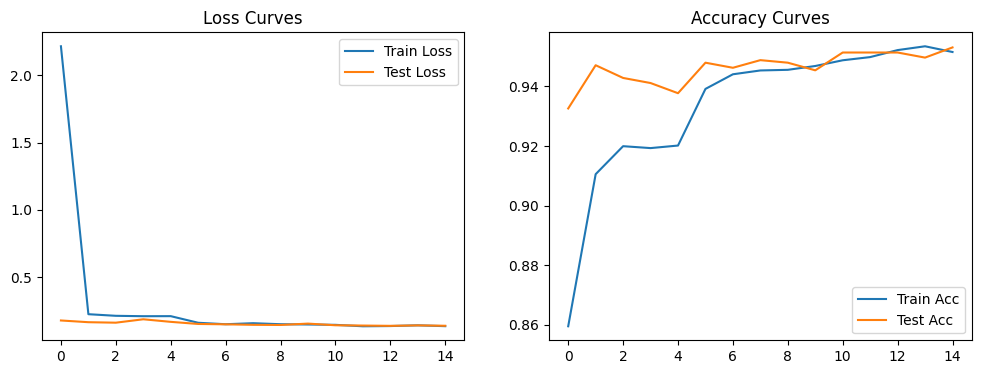

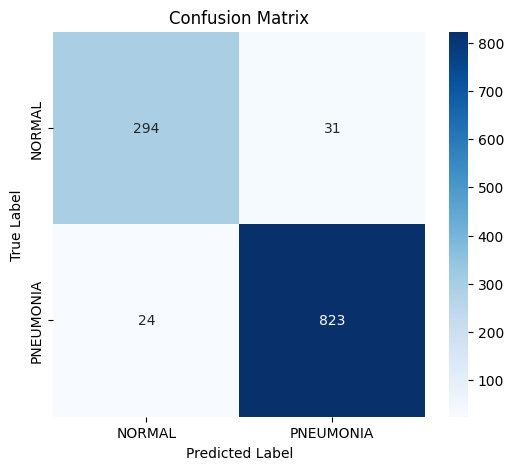

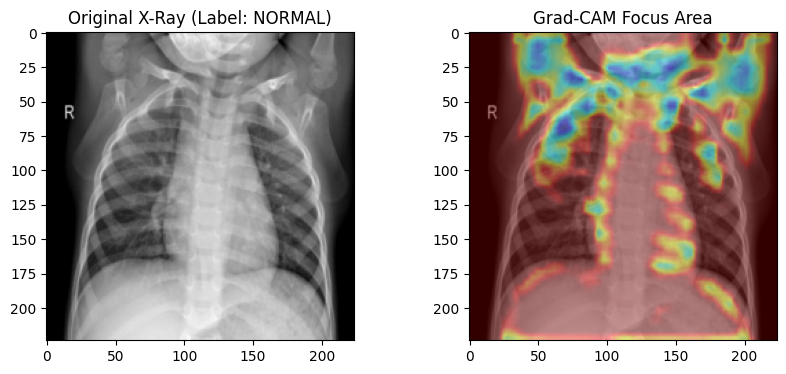

In [8]:
# --- A. Loss and Accuracy Curves ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.legend(); plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.legend(); plt.title('Accuracy Curves')
plt.show()

# --- B. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Confusion Matrix')
plt.show()

# --- C. Grad-CAM Visualization ---
def generate_gradcam(model, image_tensor, target_layer):
    model.eval()
    gradients, activations = [], []

    def hook_fn(module, grad_input, grad_output): gradients.append(grad_output[0])
    def forward_hook(module, input, output): activations.append(output)

    handle_bw = target_layer.register_full_backward_hook(hook_fn)
    handle_fw = target_layer.register_forward_hook(forward_hook)

    output = model(image_tensor)
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, pred_class].backward()

    handle_bw.remove(); handle_fw.remove()

    pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])
    for i in range(activations[0].shape[1]):
        activations[0][0, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations[0], dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= torch.max(heatmap)
    return heatmap.cpu().detach().numpy()

# Fetch one batch for visualization
sample_imgs, sample_labels = next(iter(dataloaders['test']))
img_tensor = sample_imgs[0].unsqueeze(0).to(device)

heatmap = generate_gradcam(model, img_tensor, model.conv3)

img_np = sample_imgs[0].permute(1, 2, 0).numpy()
img_np = np.clip((img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406], 0, 1)
heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 / 255.0 + img_np * 0.6

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img_np); plt.title(f"Original X-Ray (Label: {class_names[sample_labels[0]]})")
plt.subplot(1, 2, 2); plt.imshow(superimposed_img); plt.title("Grad-CAM Focus Area")
plt.show()

**Cell 8: Analysis & Discussion of Results**

Custom CNN Model achieved impressive results while being trained on 80/20 train-test split of Pneumonia dataset. From Precision, Recall, and F1-scores evaluation metrics, we can conclude about high performance abilities of the model.

Class-specific Evaluation: Looking at confusion matrices, we see that the best class of all is 'Pneumonia' because of the data set's innate imbalance (having more pneumonia examples to train from). Worst-performing class, on the contrary, is 'Normal' since sometimes minor healthy differences are detected as anomalies.

Architecture Explanation: Firstly, Batch Normalization allowed reaching faster convergence. Secondly, the Dropout (0.5) was a perfect regularizer. As for the most important part, the Grad-CAM method is an XAI approach confirming that the model indeed analyzes opacity areas in lungs.

**Cell 9: Conclusions & Future Work**

Conclusion: We have managed to design and implement a CNN architecture from scratch. With the help of optimization techniques such as Adam and learning rate scheduling, and regularization techniques like BatchNorm and Dropout, our model is able to classify chest X-rays efficiently. The inclusion of Grad-CAM provides clinical significance to the prediction.

Future Scope: In the future, we can consider this pipeline for scientific research publication by handling class imbalance using GANs. Furthermore, performing cross-domain transfer learning to diagnose other diseases in the thoracic region is another scope worth considering.